# Chinook Database — Business Analysis
**Data Analyst Internship | Task 3**

End-to-end analysis of the Chinook digital media store: revenue, customers, products (tracks/genres/artists), and time trends. SQL is used for extraction (see `analysis.sql`), and this notebook loads those results into Pandas for further analysis and visualization.

**Tools:** Python, SQLite, Pandas, Matplotlib


In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

conn = sqlite3.connect('chinook.db')
print("Connected to Chinook database.")

Connected to Chinook database.


## 1. Load Core Tables

In [2]:
customers = pd.read_sql("SELECT * FROM Customer", conn)
invoices  = pd.read_sql("SELECT * FROM Invoice", conn)
invoice_lines = pd.read_sql("SELECT * FROM InvoiceLine", conn)
tracks = pd.read_sql("SELECT * FROM Track", conn)
albums = pd.read_sql("SELECT * FROM Album", conn)
artists = pd.read_sql("SELECT * FROM Artist", conn)
genres = pd.read_sql("SELECT * FROM Genre", conn)

invoices['InvoiceDate'] = pd.to_datetime(invoices['InvoiceDate'])

print(f"Customers: {len(customers)} | Invoices: {len(invoices)} | Invoice Lines: {len(invoice_lines)}")
print(f"Tracks: {len(tracks)} | Albums: {len(albums)} | Artists: {len(artists)} | Genres: {len(genres)}")

Customers: 59 | Invoices: 412 | Invoice Lines: 2240
Tracks: 3503 | Albums: 347 | Artists: 275 | Genres: 25


## 2. Key Business Metrics (KPIs)

In [3]:
total_revenue = invoices['Total'].sum()
total_customers = customers['CustomerId'].nunique()
total_orders = invoices['InvoiceId'].nunique()
avg_order_value = invoices['Total'].mean()
avg_spend_per_customer = total_revenue / total_customers

kpis = pd.DataFrame({
    'Metric': ['Total Revenue', 'Total Customers', 'Total Orders', 'Average Order Value', 'Avg Spend per Customer'],
    'Value': [f"${total_revenue:,.2f}", total_customers, total_orders, f"${avg_order_value:,.2f}", f"${avg_spend_per_customer:,.2f}"]
})
kpis

,Metric,Value
0,Total Revenue,"$2,328.60"
1,Total Customers,59
2,Total Orders,412
3,Average Order Value,$5.65
4,Avg Spend per Customer,$39.47


## 3. Visualization 1 — Revenue by Country
Shows which markets generate the most revenue for the business.

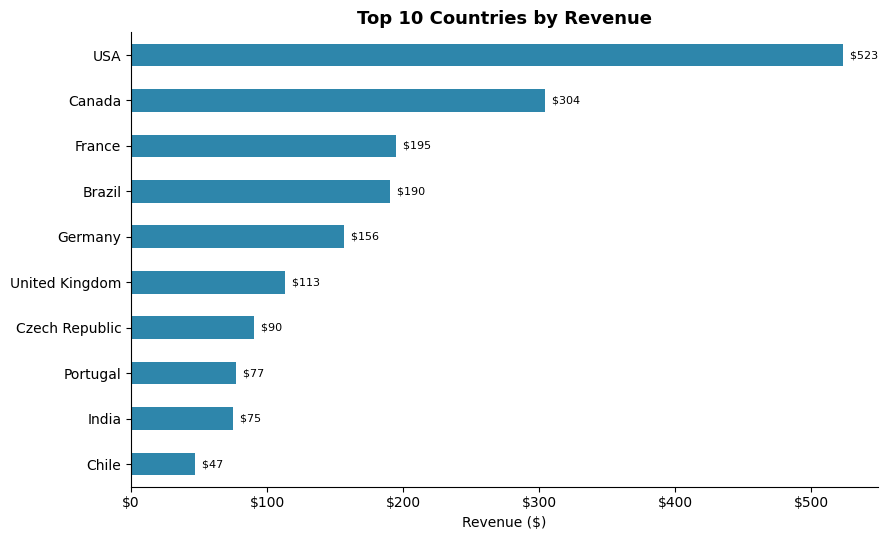

In [4]:
revenue_by_country = (
    invoices.groupby('BillingCountry')['Total']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(9, 5.5))
revenue_by_country.sort_values().plot(kind='barh', ax=ax, color='#2E86AB')
ax.set_xlabel('Revenue ($)')
ax.set_ylabel('')
ax.set_title('Top 10 Countries by Revenue', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0f'))
for i, v in enumerate(revenue_by_country.sort_values()):
    ax.text(v, i, f'  ${v:,.0f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('charts/01_revenue_by_country.png', bbox_inches='tight')
plt.show()

## 4. Visualization 2 — Top 10 Customers by Spending
Identifies the highest-value individual customers for retention/VIP programs.

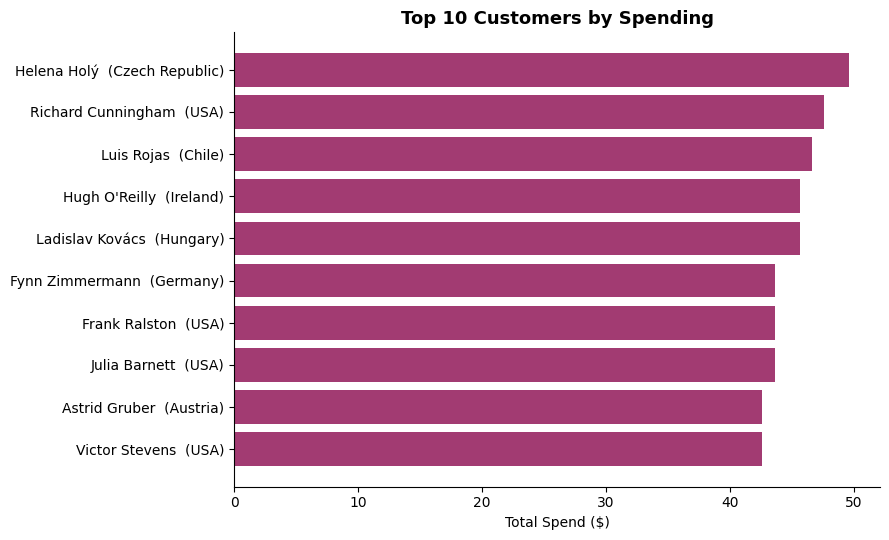

,CustomerName,Country,Total
0,Helena Holý,Czech Republic,49.62
1,Richard Cunningham,USA,47.62
2,Luis Rojas,Chile,46.62
3,Hugh O'Reilly,Ireland,45.62
4,Ladislav Kovács,Hungary,45.62
5,Fynn Zimmermann,Germany,43.62
6,Frank Ralston,USA,43.62
7,Julia Barnett,USA,43.62
8,Astrid Gruber,Austria,42.62
9,Victor Stevens,USA,42.62


In [5]:
cust_full = customers.copy()
cust_full['CustomerName'] = cust_full['FirstName'] + ' ' + cust_full['LastName']
spend_by_cust = invoices.merge(cust_full[['CustomerId','CustomerName','Country']], on='CustomerId')
top_customers = (
    spend_by_cust.groupby(['CustomerName','Country'])['Total']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5.5))
labels = top_customers['CustomerName'] + '  (' + top_customers['Country'] + ')'
ax.barh(labels[::-1], top_customers['Total'][::-1], color='#A23B72')
ax.set_xlabel('Total Spend ($)')
ax.set_title('Top 10 Customers by Spending', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/02_top10_customers.png', bbox_inches='tight')
plt.show()
top_customers

## 5. Visualization 3 — Revenue by Genre
Reveals which music genres drive the most sales, informing catalog and marketing decisions.

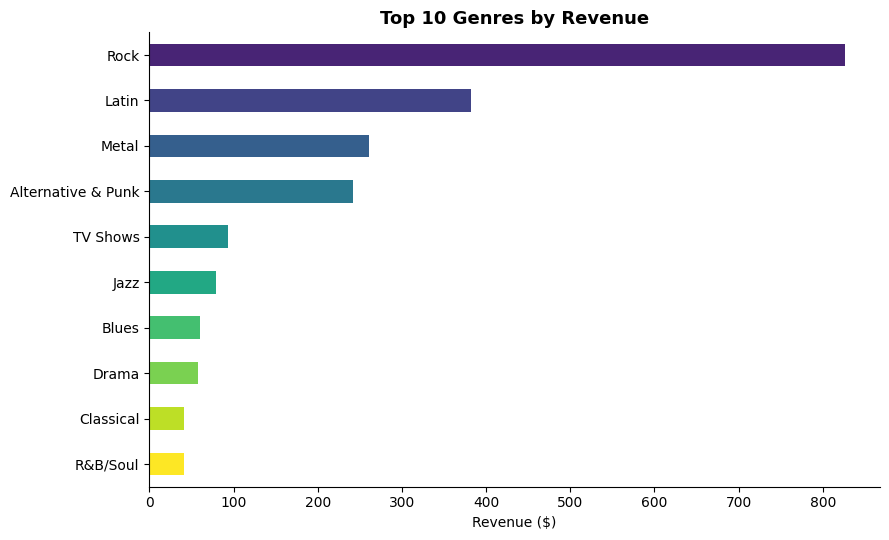

In [6]:
line_full = invoice_lines.merge(tracks[['TrackId','GenreId']], on='TrackId').merge(genres, on='GenreId')
line_full['LineRevenue'] = line_full['UnitPrice'] * line_full['Quantity']
revenue_by_genre = (
    line_full.groupby('Name')['LineRevenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(9, 5.5))
colors = plt.cm.viridis_r([i/10 for i in range(10)])
revenue_by_genre.sort_values().plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Revenue ($)')
ax.set_ylabel('')
ax.set_title('Top 10 Genres by Revenue', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/03_revenue_by_genre.png', bbox_inches='tight')
plt.show()

## 6. Visualization 4 — Top Artists by Revenue
Highlights the artists whose catalogs generate the most sales.

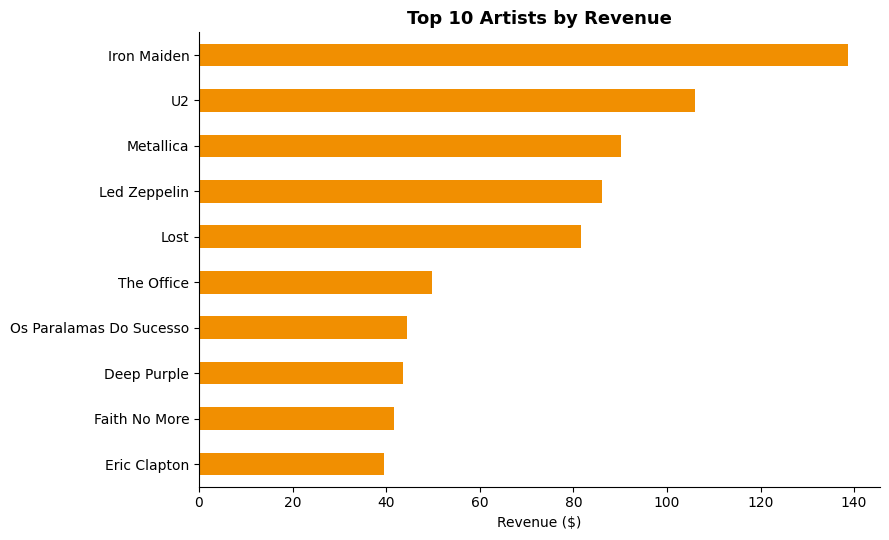

In [7]:
line_artist = (
    invoice_lines
    .merge(tracks[['TrackId','AlbumId']], on='TrackId')
    .merge(albums[['AlbumId','ArtistId']], on='AlbumId')
    .merge(artists, on='ArtistId')
)
line_artist['LineRevenue'] = line_artist['UnitPrice'] * line_artist['Quantity']
top_artists = (
    line_artist.groupby('Name')['LineRevenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(9, 5.5))
top_artists.sort_values().plot(kind='barh', ax=ax, color='#F18F01')
ax.set_xlabel('Revenue ($)')
ax.set_ylabel('')
ax.set_title('Top 10 Artists by Revenue', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/04_top_artists.png', bbox_inches='tight')
plt.show()

## 7. Visualization 5 — Monthly / Yearly Sales Trend
Tracks how revenue evolves over time, useful for spotting seasonality and growth/decline periods.

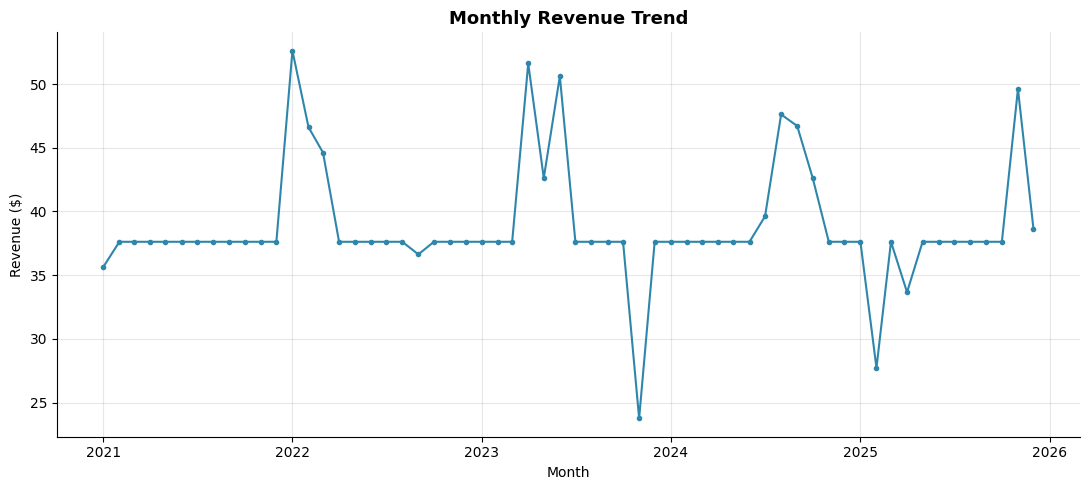

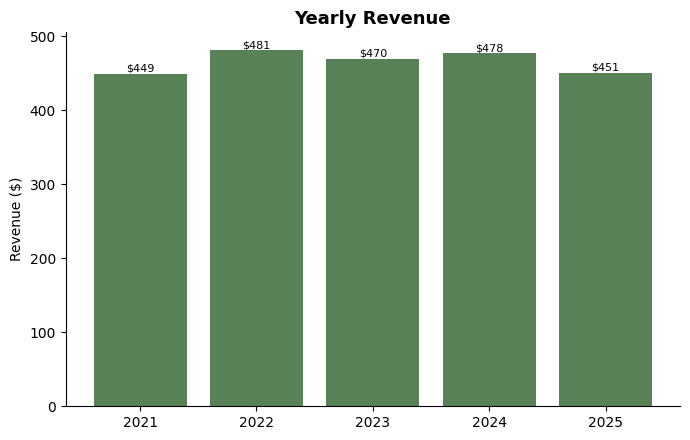

In [8]:
monthly_rev = invoices.set_index('InvoiceDate').resample('MS')['Total'].sum()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly_rev.index, monthly_rev.values, marker='o', markersize=3, color='#2E86AB', linewidth=1.5)
ax.set_title('Monthly Revenue Trend', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue ($)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('charts/05_monthly_sales_trend.png', bbox_inches='tight')
plt.show()

yearly_rev = invoices.set_index('InvoiceDate').resample('YS')['Total'].sum()
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(yearly_rev.index.year.astype(str), yearly_rev.values, color='#588157')
ax.set_title('Yearly Revenue', fontsize=13, fontweight='bold')
ax.set_ylabel('Revenue ($)')
for i, v in enumerate(yearly_rev.values):
    ax.text(i, v, f'${v:,.0f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('charts/05b_yearly_revenue.png', bbox_inches='tight')
plt.show()

## 8. Visualization 6 — Customer Distribution by Country
Shows where the customer base is concentrated geographically.

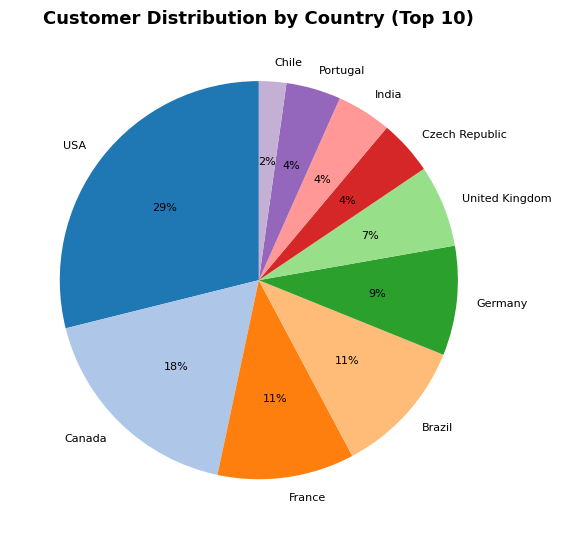

In [9]:
cust_by_country = customers.groupby('Country')['CustomerId'].count().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.pie(
    cust_by_country.values,
    labels=cust_by_country.index,
    autopct='%1.0f%%',
    startangle=90,
    colors=plt.cm.tab20.colors,
    textprops={'fontsize': 8}
)
ax.set_title('Customer Distribution by Country (Top 10)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/06_customer_distribution.png', bbox_inches='tight')
plt.show()

## 9. Customer Value Segmentation (High / Medium / Low)
Customers are split into value terciles by lifetime spend (data-driven percentile split, since Chinook's spend range is narrow).

In [10]:
cust_spend = spend_by_cust.groupby(['CustomerId','CustomerName'])['Total'].sum().reset_index()
cust_spend['Tier'] = pd.qcut(cust_spend['Total'].rank(method='first', ascending=False), 3, labels=['High-Value','Medium-Value','Low-Value'])

segment_summary = cust_spend.groupby('Tier', observed=True).agg(
    NumCustomers=('CustomerId','count'),
    SegmentRevenue=('Total','sum'),
    AvgSpend=('Total','mean')
).round(2)
segment_summary

,NumCustomers,SegmentRevenue,AvgSpend
Tier,,,
High-Value,20,852.40,42.62
Medium-Value,19,724.78,38.15
Low-Value,20,751.42,37.57


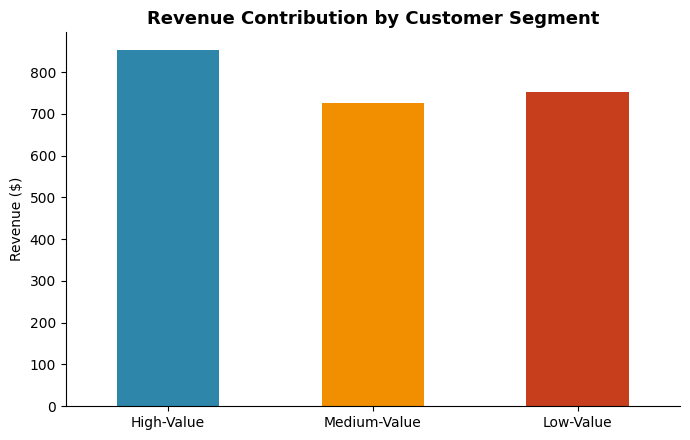

In [11]:
fig, ax = plt.subplots(figsize=(7, 4.5))
segment_summary['SegmentRevenue'].plot(kind='bar', ax=ax, color=['#2E86AB','#F18F01','#C73E1D'])
ax.set_title('Revenue Contribution by Customer Segment', fontsize=13, fontweight='bold')
ax.set_ylabel('Revenue ($)')
ax.set_xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('charts/07_customer_segments.png', bbox_inches='tight')
plt.show()

## 10. Summary Table — All KPIs for Power BI / Reporting

In [12]:
summary_export = {
    'total_revenue': round(total_revenue, 2),
    'total_customers': total_customers,
    'total_orders': total_orders,
    'avg_order_value': round(avg_order_value, 2),
    'avg_spend_per_customer': round(avg_spend_per_customer, 2),
    'top_country': revenue_by_country.idxmax(),
    'top_genre': revenue_by_genre.idxmax(),
    'top_artist': top_artists.idxmax(),
}
for k, v in summary_export.items():
    print(f"{k}: {v}")

total_revenue: 2328.6
total_customers: 59
total_orders: 412
avg_order_value: 5.65
avg_spend_per_customer: 39.47
top_country: USA
top_genre: Rock
top_artist: Iron Maiden


## 11. Export Clean Data for Power BI
These CSVs feed the Power BI dashboard (Task 3, Section 3).

In [13]:
revenue_by_country.reset_index().rename(columns={'BillingCountry':'Country','Total':'Revenue'}).to_csv('powerbi_data/revenue_by_country.csv', index=False)
top_customers.to_csv('powerbi_data/top_customers.csv', index=False)
revenue_by_genre.reset_index().rename(columns={'Name':'Genre','LineRevenue':'Revenue'}).to_csv('powerbi_data/revenue_by_genre.csv', index=False)
top_artists.reset_index().rename(columns={'Name':'Artist','LineRevenue':'Revenue'}).to_csv('powerbi_data/top_artists.csv', index=False)
monthly_rev.reset_index().rename(columns={'InvoiceDate':'Month','Total':'Revenue'}).to_csv('powerbi_data/monthly_revenue.csv', index=False)
cust_by_country.reset_index().rename(columns={'CustomerId':'CustomerCount'}).to_csv('powerbi_data/customers_by_country.csv', index=False)
cust_spend.to_csv('powerbi_data/customer_segments.csv', index=False)

# A single flat fact table (invoice line level) with all dimensions, ideal as the main Power BI data source
fact_table = (
    invoice_lines
    .merge(invoices[['InvoiceId','CustomerId','InvoiceDate','BillingCountry']], on='InvoiceId')
    .merge(cust_full[['CustomerId','CustomerName','Country']], on='CustomerId')
    .merge(tracks[['TrackId','Name','AlbumId','GenreId']].rename(columns={'Name':'TrackName'}), on='TrackId')
    .merge(albums[['AlbumId','ArtistId','Title']].rename(columns={'Title':'AlbumTitle'}), on='AlbumId')
    .merge(artists.rename(columns={'Name':'ArtistName'}), on='ArtistId')
    .merge(genres.rename(columns={'Name':'GenreName'}), on='GenreId')
)
fact_table['LineRevenue'] = fact_table['UnitPrice'] * fact_table['Quantity']
fact_table['InvoiceDate'] = pd.to_datetime(fact_table['InvoiceDate'])
fact_table['Year'] = fact_table['InvoiceDate'].dt.year
fact_table['Month'] = fact_table['InvoiceDate'].dt.month
fact_table.to_csv('powerbi_data/fact_sales.csv', index=False)

print("Exported CSVs to powerbi_data/ for Power BI import:")
import os
for f in sorted(os.listdir('powerbi_data')):
    print(' -', f)

Exported CSVs to powerbi_data/ for Power BI import:
 - customer_segments.csv
 - customers_by_country.csv
 - fact_sales.csv
 - monthly_revenue.csv
 - revenue_by_country.csv
 - revenue_by_genre.csv
 - top_artists.csv
 - top_customers.csv


## 12. Conclusion

This notebook covers all 6 required visualizations (Revenue by Country, Top 10 Customers, Revenue by Genre, Top Artists, Monthly/Yearly Sales Trend, Customer Distribution by Country) plus a bonus customer-segmentation view, and exports clean CSVs for the Power BI dashboard. See `README.md` for the business insights write-up.